# Appendix A - Exploratory Data Analysis (EDA)

This notebook is part of the reproducibility package for the MSc thesis **Probabilistic Machine Learning Models and Decision Optimization for Hepatocellular Carcinoma Diagnosis**.

> Repository note: paths are resolved from either the repository root or the `notebooks/` directory. Generated figures are written under `outputs/`.


In [1]:
from pathlib import Path
# =========================================
# Exploratory Data Analysis (EDA) - Liver Cancer
# =========================================
# Resolve repository root for reproducible relative paths
REPO_ROOT = Path.cwd()
if not (REPO_ROOT / "data").exists() and (REPO_ROOT.parent / "data").exists():
    REPO_ROOT = REPO_ROOT.parent


In [2]:
import os
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
# Global display / theme
pd.set_option("display.max_columns", 120)
pd.set_option("display.width", 160)
pd.set_option("display.float_format", lambda x: f"{x:0.4f}")

In [4]:
# seaborn theme + unified palette
sns.set_theme(style="whitegrid", font_scale=0.7)
PALETTE_CONT = "rocket"                     # continuous colormap (matches heatmap hues)
PALETTE_DISC = sns.color_palette("rocket", 6)  # discrete palette for bars/lines
CLASS_PALETTE = sns.color_palette("rocket", 2) # for target=0/1

In [5]:
plt.rcParams["figure.figsize"] = (3.5, 2.6)
plt.rcParams["axes.titlesize"] = 10
plt.rcParams["axes.labelsize"] = 9

In [6]:
# Load data
df = pd.read_csv(REPO_ROOT / "data" / "synthetic_liver_cancer_dataset.csv")
TARGET = "liver_cancer"

In [7]:
# File for Tables & Figures
out_dir = REPO_ROOT / "outputs" / "eda"
os.makedirs(out_dir, exist_ok=True)

In [8]:
y = df[TARGET].astype(int)
X = df.drop(columns=[TARGET])

In [9]:
print("First Rows:")
df.head()

First Rows:


,age,gender,bmi,alcohol_consumption,smoking_status,hepatitis_b,hepatitis_c,liver_function_score,alpha_fetoprotein_level,cirrhosis_history,family_history_cancer,physical_activity_level,diabetes,liver_cancer
0,68,Female,18.1000,Regular,Former,0,0,51.9000,16.4400,0,0,Low,0,0
1,81,Female,19.9000,Occasional,Never,0,0,41.6000,8.0900,0,0,Moderate,1,0
2,58,Female,25.5000,Never,Never,0,0,76.0000,0.6400,0,0,Moderate,0,0
3,44,Male,16.0000,Never,Former,0,0,50.3000,19.0900,0,0,Low,1,0
4,72,Male,21.0000,Occasional,Former,0,0,39.5000,4.9500,1,0,Low,1,1


In [10]:
num_cols = X.select_dtypes(include=[np.number]).columns.tolist()
cat_cols = X.select_dtypes(include=["object", "category", "bool"]).columns.tolist()

In [11]:
print("Shape (rows, cols):", df.shape)
print("\nDtypes:\n", df.dtypes)

Shape (rows, cols): (5000, 14)

Dtypes:
 age                          int64
gender                      object
bmi                        float64
alcohol_consumption         object
smoking_status              object
hepatitis_b                  int64
hepatitis_c                  int64
liver_function_score       float64
alpha_fetoprotein_level    float64
cirrhosis_history            int64
family_history_cancer        int64
physical_activity_level     object
diabetes                     int64
liver_cancer                 int64
dtype: object


In [12]:
# Missingness & class balance
missing_tbl = (df.isna().sum()
                 .to_frame("missing_count")
                 .assign(missing_rate=lambda d: d["missing_count"]/len(df))
                 .sort_values("missing_rate", ascending=False))
display(missing_tbl)


balance = (y.value_counts().rename_axis(TARGET)
             .to_frame("count")
             .assign(ratio=lambda s: s["count"]/len(y))
             .sort_index())
display(balance)

,missing_count,missing_rate
age,0,0.0000
gender,0,0.0000
bmi,0,0.0000
alcohol_consumption,0,0.0000
smoking_status,0,0.0000
hepatitis_b,0,0.0000
hepatitis_c,0,0.0000
liver_function_score,0,0.0000
alpha_fetoprotein_level,0,0.0000
cirrhosis_history,0,0.0000


,count,ratio
liver_cancer,,
0,3911,0.7822
1,1089,0.2178


In [13]:
# Descriptive statistics for numeric variables
desc_num = df[num_cols].describe().T
desc_num["skew"] = df[num_cols].skew(numeric_only=True)
desc_num["kurtosis"] = df[num_cols].kurtosis(numeric_only=True)
display(desc_num)

,count,mean,std,min,25%,50%,75%,max,skew,kurtosis
age,5000.0000,57.2228,15.7992,30.0000,44.0000,57.0000,71.0000,84.0000,-0.0183,-1.1765
bmi,5000.0000,25.9046,5.1052,8.1000,22.5000,25.9000,29.3000,43.7000,-0.0120,-0.0030
hepatitis_b,5000.0000,0.1512,0.3583,0.0000,0.0000,0.0000,0.0000,1.0000,1.9479,1.7949
hepatitis_c,5000.0000,0.0958,0.2943,0.0000,0.0000,0.0000,0.0000,1.0000,2.7475,5.5511
liver_function_score,5000.0000,65.2039,14.8755,5.5000,54.8000,65.2000,75.2000,115.7000,0.0146,-0.0332
alpha_fetoprotein_level,5000.0000,15.1094,15.1968,0.0000,4.3575,10.3400,21.0100,136.8000,1.9450,5.1829
cirrhosis_history,5000.0000,0.3016,0.4590,0.0000,0.0000,0.0000,1.0000,1.0000,0.8648,-1.2526
family_history_cancer,5000.0000,0.2414,0.4280,0.0000,0.0000,0.0000,0.0000,1.0000,1.2090,-0.5386
diabetes,5000.0000,0.1992,0.3994,0.0000,0.0000,0.0000,0.0000,1.0000,1.5067,0.2703


In [14]:
# Descriptive statistics for categorical variables
rows = []
for c in cat_cols:
    vc = df[c].value_counts(dropna=False)
    rows.append({
        "variable": c,
        "n_unique": df[c].nunique(dropna=True),
        "n_missing": int(df[c].isna().sum()),
        "top_category": (str(vc.index[0]) if len(vc) else np.nan),
        "top_freq": (int(vc.iloc[0]) if len(vc) else np.nan)
    })
desc_cat = pd.DataFrame(rows).sort_values("n_unique", ascending=False)
display(desc_cat)

,variable,n_unique,n_missing,top_category,top_freq
1,alcohol_consumption,3,0,Never,2014
2,smoking_status,3,0,Never,2407
3,physical_activity_level,3,0,Moderate,2027
0,gender,2,0,Female,2506


In [15]:
# Zero-scan (numeric)
zero_tbl = pd.DataFrame({
    "variable": num_cols,
    "n_zero": [int((df[c] == 0).sum()) for c in num_cols]
})
zero_tbl["zero_rate"] = zero_tbl["n_zero"] / len(df)
display(zero_tbl.sort_values("zero_rate", ascending=False))

,variable,n_zero,zero_rate
3,hepatitis_c,4521,0.9042
2,hepatitis_b,4244,0.8488
8,diabetes,4004,0.8008
7,family_history_cancer,3793,0.7586
6,cirrhosis_history,3492,0.6984
5,alpha_fetoprotein_level,1,0.0002
0,age,0,0.0000
4,liver_function_score,0,0.0000
1,bmi,0,0.0000


In [16]:
# Univariate EDA — numeric (histogram + KDE) with thesis hues

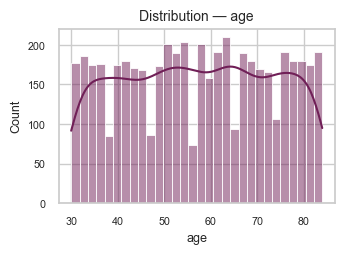

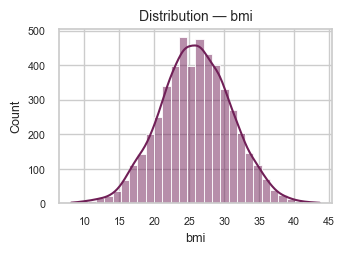

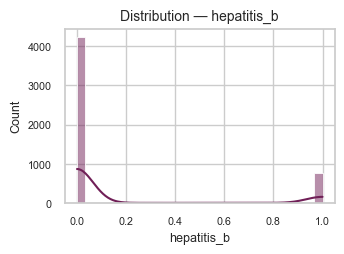

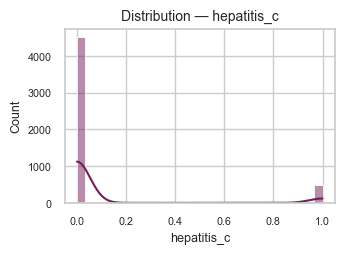

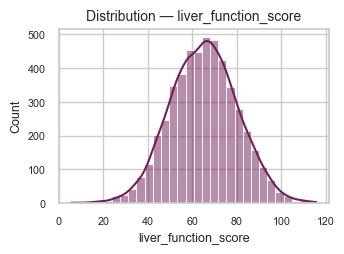

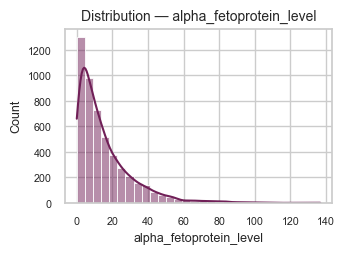

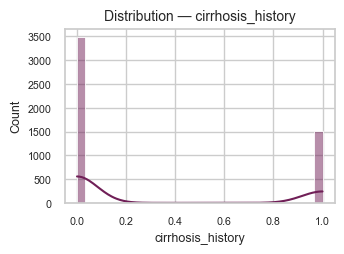

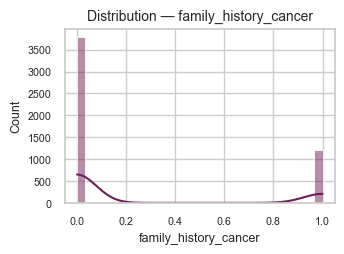

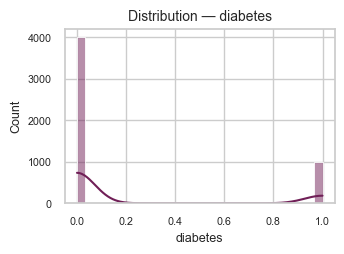

In [17]:
for c in num_cols:
    plt.figure()
    sns.histplot(df, x=c, bins=30, kde=True, color=PALETTE_DISC[1], edgecolor="white")
    plt.title(f"Distribution — {c}")
    plt.xlabel(c)
    plt.ylabel("Count")
    plt.tight_layout()
    plt.savefig(f"{out_dir}/hist_{c}.png", dpi=300)
    plt.show()

In [18]:
# Numeric vs Target — box/violin (legend outside)

C:\Users\thano\AppData\Local\Temp\ipykernel_3948\4086991379.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=df, x=TARGET, y=c, palette=CLASS_PALETTE, cut=0, inner="quartile")


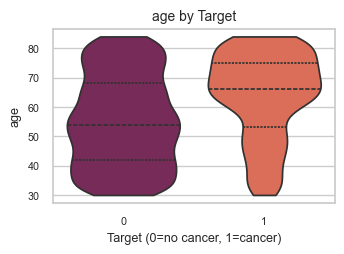

C:\Users\thano\AppData\Local\Temp\ipykernel_3948\4086991379.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=df, x=TARGET, y=c, palette=CLASS_PALETTE, cut=0, inner="quartile")


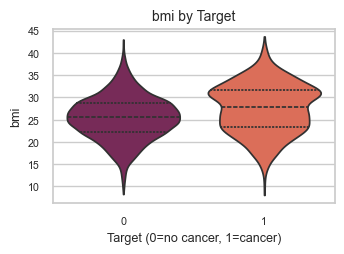

C:\Users\thano\AppData\Local\Temp\ipykernel_3948\4086991379.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=df, x=TARGET, y=c, palette=CLASS_PALETTE, cut=0, inner="quartile")


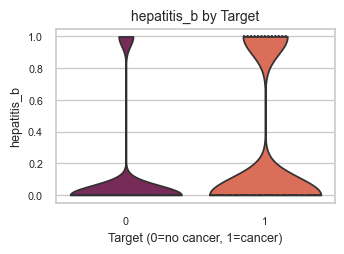

C:\Users\thano\AppData\Local\Temp\ipykernel_3948\4086991379.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=df, x=TARGET, y=c, palette=CLASS_PALETTE, cut=0, inner="quartile")


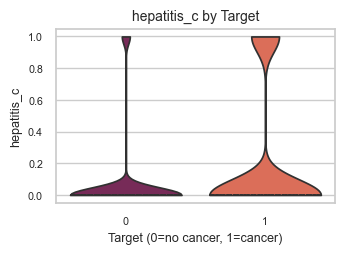

C:\Users\thano\AppData\Local\Temp\ipykernel_3948\4086991379.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=df, x=TARGET, y=c, palette=CLASS_PALETTE, cut=0, inner="quartile")


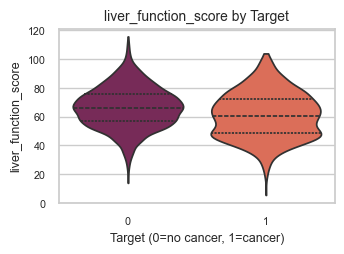

C:\Users\thano\AppData\Local\Temp\ipykernel_3948\4086991379.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=df, x=TARGET, y=c, palette=CLASS_PALETTE, cut=0, inner="quartile")


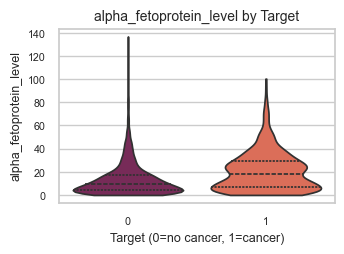

C:\Users\thano\AppData\Local\Temp\ipykernel_3948\4086991379.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=df, x=TARGET, y=c, palette=CLASS_PALETTE, cut=0, inner="quartile")


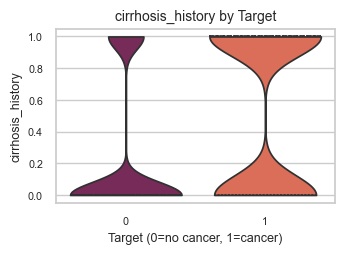

C:\Users\thano\AppData\Local\Temp\ipykernel_3948\4086991379.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=df, x=TARGET, y=c, palette=CLASS_PALETTE, cut=0, inner="quartile")


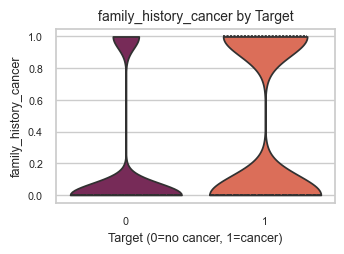

C:\Users\thano\AppData\Local\Temp\ipykernel_3948\4086991379.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=df, x=TARGET, y=c, palette=CLASS_PALETTE, cut=0, inner="quartile")


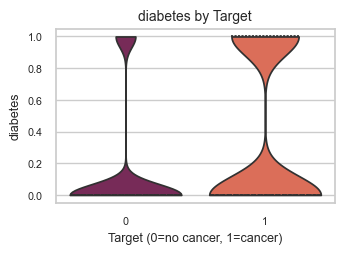

In [19]:
for c in num_cols:
    plt.figure()
    sns.violinplot(data=df, x=TARGET, y=c, hue=TARGET, palette=CLASS_PALETTE, legend=False, cut=0, inner="quartile")
    plt.title(f"{c} by Target")
    plt.xlabel("Target (0=no cancer, 1=cancer)")
    plt.tight_layout()
    plt.savefig(f"{out_dir}/violin_{c}_by_target.png", dpi=300)
    plt.show()

In [20]:
# Categorical — countplots (overall) and by target (stacked via hue)

C:\Users\thano\AppData\Local\Temp\ipykernel_3948\761372483.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x=c, palette=PALETTE_DISC)
C:\Users\thano\AppData\Local\Temp\ipykernel_3948\761372483.py:4: UserWarning: The palette list has more values (6) than needed (2), which may not be intended.
  sns.countplot(data=df, x=c, palette=PALETTE_DISC)


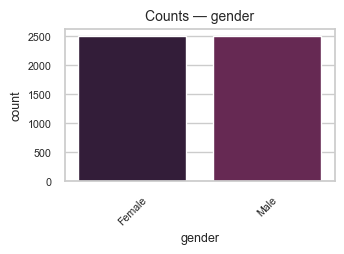

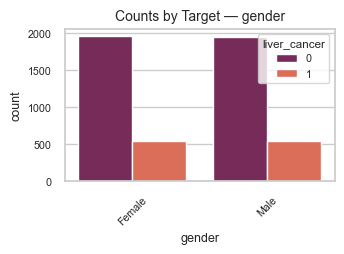

C:\Users\thano\AppData\Local\Temp\ipykernel_3948\761372483.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x=c, palette=PALETTE_DISC)
C:\Users\thano\AppData\Local\Temp\ipykernel_3948\761372483.py:4: UserWarning: The palette list has more values (6) than needed (3), which may not be intended.
  sns.countplot(data=df, x=c, palette=PALETTE_DISC)


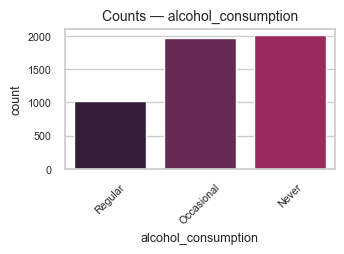

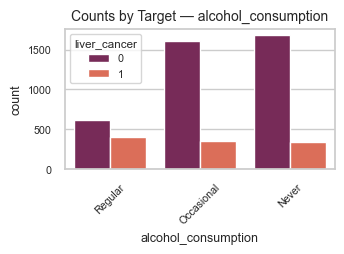

C:\Users\thano\AppData\Local\Temp\ipykernel_3948\761372483.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x=c, palette=PALETTE_DISC)
C:\Users\thano\AppData\Local\Temp\ipykernel_3948\761372483.py:4: UserWarning: The palette list has more values (6) than needed (3), which may not be intended.
  sns.countplot(data=df, x=c, palette=PALETTE_DISC)


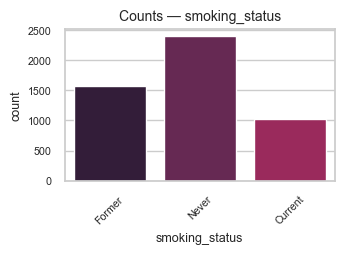

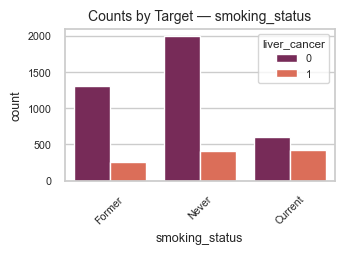

C:\Users\thano\AppData\Local\Temp\ipykernel_3948\761372483.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x=c, palette=PALETTE_DISC)
C:\Users\thano\AppData\Local\Temp\ipykernel_3948\761372483.py:4: UserWarning: The palette list has more values (6) than needed (3), which may not be intended.
  sns.countplot(data=df, x=c, palette=PALETTE_DISC)


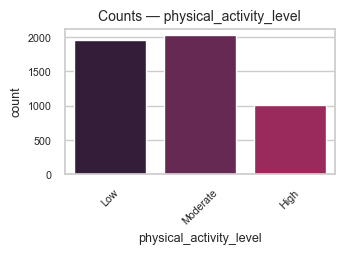

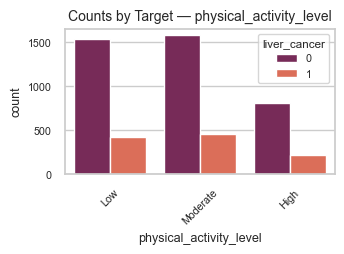

In [21]:
for c in cat_cols:
    # overall
    plt.figure()
    sns.countplot(data=df, x=c, color=PALETTE_DISC[0])
    plt.title(f"Counts — {c}")
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.savefig(f"{out_dir}/count_{c}.png", dpi=150)
    plt.show()

    # by target
    plt.figure()
    sns.countplot(data=df, x=c, hue=TARGET, palette=CLASS_PALETTE)
    plt.title(f"Counts by Target — {c}")
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.savefig(f"{out_dir}/count_{c}_by_target.png", dpi=300)
    plt.show()

In [22]:
# Target-wise numeric summary table

In [23]:
grp_num = df.groupby(TARGET)[num_cols].agg(["count", "mean", "std", "median", "min", "max"])
display(grp_num)

age                                   bmi                                       hepatitis_b                              hepatitis_c         \
             count    mean     std  median min max count    mean    std  median    min     max       count   mean    std median min max       count   mean   
liver_cancer                                                                                                                                                 
0             3911 55.4127 15.6032 54.0000  30  84  3911 25.4480 4.8797 25.5000 8.3000 43.0000        3911 0.1140 0.3179 0.0000   0   1        3911 0.0670   
1             1089 63.7236 14.7610 66.0000  30  84  1089 27.5446 5.5442 27.9000 8.1000 43.7000        1089 0.2847 0.4515 0.0000   0   1        1089 0.1993   

                                   liver_function_score                                          alpha_fetoprotein_level                                 \
                std median min max                count    mean     std  median     min      max                   count    mean     std  median    min   
liver_cancer                                                                                                                                              
0            0.2500 0.0000   0   1                 3911 66.3509 14.3425 66.2000 13.9000 115.7000                    3911 13.5384 14.2123  9.2600 0.0000   
1            0.3996 0.0000   0   1                 1089 61.0846 15.9917 60.7000  5.5000 103.9000                    1089 20.7516 17.1601 18.0100 0.0200   

                      cirrhosis_history                              family_history_cancer                              diabetes                               
                  max             count   mean    std median min max                 count   mean    std median min max    count   mean    std median min max  
liver_cancer                                                                                                                                                   
0            136.8000              3911 0.2401 0.4272 0.0000   0   1                  3911 0.1890 0.3915 0.0000   0   1     3911 0.1501 0.3572 0.0000   0   1  
1            100.3600              1089 0.5225 0.4997 1.0000   0   1                  1089 0.4298 0.4953 0.0000   0   1     1089 0.3756 0.4845 0.0000   0   1

In [24]:
# Correlations — Spearman (numeric) + heatmap with 'rocket' hues

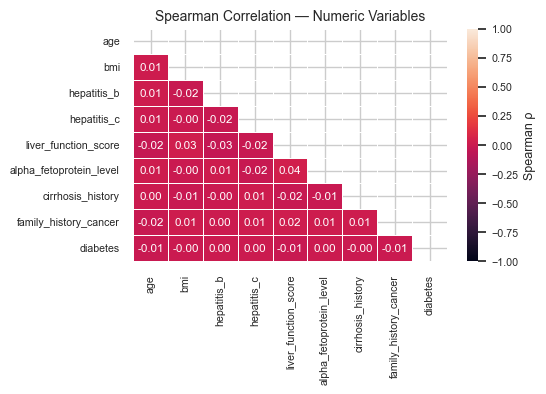

In [25]:
if len(num_cols) >= 2:
    corr = df[num_cols].corr(method="spearman")
    mask = np.triu(np.ones_like(corr, dtype=bool))
    plt.figure(figsize=(5.5, 4.0))
    sns.heatmap(corr, mask=mask, cmap=PALETTE_CONT, vmin=-1, vmax=1, center=0,
                annot=True, fmt=".2f", linewidths=0.6, linecolor="white",
                cbar_kws={"label": "Spearman ρ"})
    plt.title("Spearman Correlation — Numeric Variables")
    plt.tight_layout()
    plt.savefig(f"{out_dir}/spearman_corr.png", dpi=300)
    plt.show()

In [26]:
# Point-biserial (numeric vs target) — Pearson with {0,1} target

In [27]:
pb_vals = []
yt = y.astype(float).values
for c in num_cols:
    xv = df[c].values
    mask = ~pd.isna(xv)
    xv = xv[mask]; yv = yt[mask]
    if xv.size > 2 and np.std(xv) > 0:
        r = np.corrcoef(xv, yv)[0,1]
    else:
        r = np.nan
    pb_vals.append((c, r, abs(r)))

pb_df = (pd.DataFrame(pb_vals, columns=["variable","r","abs_r"])
           .sort_values("abs_r", ascending=False))
display(pb_df)

,variable,r,abs_r
6,cirrhosis_history,0.2540,0.2540
8,diabetes,0.2330,0.2330
7,family_history_cancer,0.2323,0.2323
0,age,0.2171,0.2171
2,hepatitis_b,0.1966,0.1966
5,alpha_fetoprotein_level,0.1959,0.1959
3,hepatitis_c,0.1855,0.1855
1,bmi,0.1695,0.1695
4,liver_function_score,-0.1461,0.1461


C:\Users\thano\AppData\Local\Temp\ipykernel_3948\600042791.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=pb_df, x="abs_r", y="variable", palette=PALETTE_DISC)
C:\Users\thano\AppData\Local\Temp\ipykernel_3948\600042791.py:2: UserWarning: 
The palette list has fewer values (6) than needed (9) and will cycle, which may produce an uninterpretable plot.
  sns.barplot(data=pb_df, x="abs_r", y="variable", palette=PALETTE_DISC)


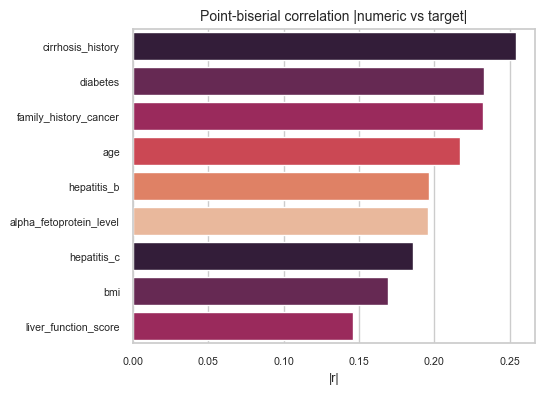

In [28]:
plt.figure(figsize=(5.5, 4.0))
sns.barplot(data=pb_df, x="abs_r", y="variable", color=PALETTE_DISC[0])
plt.title("Point-biserial correlation |numeric vs target|")
plt.xlabel("|r|")
plt.ylabel("")
plt.tight_layout()
plt.savefig(f"{out_dir}/point_biserial_barplot.png", dpi=300)
plt.show()

In [29]:
# Chi-square & Cramér’s V (categorical vs target) — with seaborn bars

In [30]:
chi_rows = []
for c in cat_cols:
    ct = pd.crosstab(df[c], y)
    obs = ct.values.astype(float)
    if obs.size == 0:
        continue
    row_sum = obs.sum(axis=1, keepdims=True)
    col_sum = obs.sum(axis=0, keepdims=True)
    total = obs.sum()
    exp = (row_sum @ col_sum) / total
    with np.errstate(divide='ignore', invalid='ignore'):
        chi2 = np.nansum((obs - exp)**2 / exp)
    r, k = obs.shape
    phi2 = chi2 / total if total > 0 else np.nan
    # bias-corrected Cramér’s V
    if total > 1:
        phi2corr = max(0, phi2 - ((k-1)*(r-1))/(total-1))
        rcorr = r - ((r-1)**2)/(total-1)
        kcorr = k - ((k-1)**2)/(total-1)
        denom = max(1e-12, min((kcorr-1), (rcorr-1)))
        V = np.sqrt(phi2corr / denom)
    else:
        V = np.nan
    chi_rows.append({"variable": c, "chi2": chi2, "dof": (r-1)*(k-1), "cramers_v": V})

cat_assoc = pd.DataFrame(chi_rows).sort_values("cramers_v", ascending=False)
display(cat_assoc)

,variable,chi2,dof,cramers_v
2,smoking_status,273.3028,2,0.2330
1,alcohol_consumption,233.1374,2,0.2150
0,gender,0.0031,1,0.0000
3,physical_activity_level,1.1907,2,0.0000


C:\Users\thano\AppData\Local\Temp\ipykernel_3948\3477993648.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=cat_assoc, x="cramers_v", y="variable", palette=PALETTE_DISC)
C:\Users\thano\AppData\Local\Temp\ipykernel_3948\3477993648.py:2: UserWarning: The palette list has more values (6) than needed (4), which may not be intended.
  sns.barplot(data=cat_assoc, x="cramers_v", y="variable", palette=PALETTE_DISC)


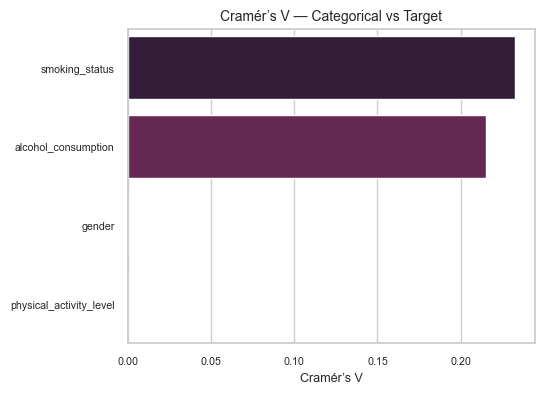

In [31]:
plt.figure(figsize=(5.5, 4.0))
sns.barplot(data=cat_assoc, x="cramers_v", y="variable", color=PALETTE_DISC[0])
plt.title("Cramér’s V — Categorical vs Target")
plt.xlabel("Cramér’s V")
plt.ylabel("")
plt.tight_layout()
plt.savefig(f"{out_dir}/cramersV_barplot.png", dpi=300)
plt.show()

In [32]:
# Stacked proportions by target (visual association) — legend on right

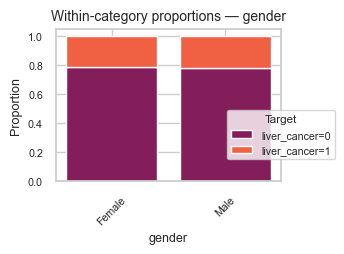

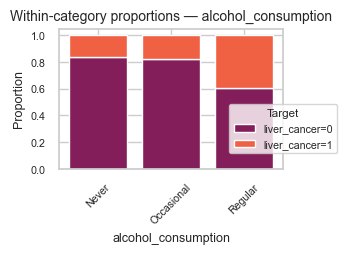

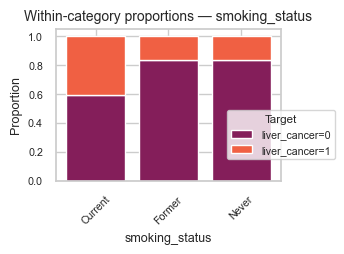

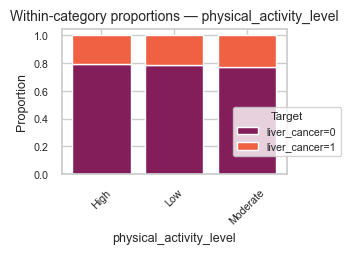

In [33]:
for c in cat_cols:
    ct = pd.crosstab(df[c], y, normalize="index")
    plt.figure()
    bottoms = np.zeros(len(ct))
    for k_idx, k in enumerate(ct.columns):
        plt.bar(ct.index.astype(str), ct[k].values, bottom=bottoms,
                label=f"{TARGET}={int(k)}", color=CLASS_PALETTE[k_idx])
        bottoms += ct[k].values
    plt.title(f"Within-category proportions — {c}")
    plt.xlabel(c)
    plt.ylabel("Proportion")
    plt.xticks(rotation=45)
    plt.legend(title="Target", loc="upper center", bbox_to_anchor=(1.0, 0.5))
    plt.tight_layout()
    plt.savefig(f"{out_dir}/stacked_prop_{c}.png", dpi=300)
    plt.show()